In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pickle

In [8]:
data = pd.read_csv("GaltonFamilies.csv")
data

,rownames,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,001,78.5,67.0,75.43,4,1,male,73.2
1,2,001,78.5,67.0,75.43,4,2,female,69.2
2,3,001,78.5,67.0,75.43,4,3,female,69.0
3,4,001,78.5,67.0,75.43,4,4,female,69.0
4,5,002,75.5,66.5,73.66,4,1,male,73.5
...,...,...,...,...,...,...,...,...,...
929,930,203,62.0,66.0,66.64,3,1,male,64.0
930,931,203,62.0,66.0,66.64,3,2,female,62.0
931,932,203,62.0,66.0,66.64,3,3,female,61.0
932,933,204,62.5,63.0,65.27,2,1,male,66.5


In [9]:
data = pd.read_csv("GaltonFamilies.csv")
data['Height'] = data['childHeight']
data = data.drop(columns = ['childHeight','rownames','family','midparentHeight'])

label_encoder = LabelEncoder()
data['gender'] = label_encoder.fit_transform(data['gender'])
data['father'] = data['father']*2.54
data['mother'] = data['mother']*2.54
data['Height'] = data['Height']*2.54
data


,father,mother,children,childNum,gender,Height
0,199.39,170.18,4,1,1,185.928
1,199.39,170.18,4,2,0,175.768
2,199.39,170.18,4,3,0,175.260
3,199.39,170.18,4,4,0,175.260
4,191.77,168.91,4,1,1,186.690
...,...,...,...,...,...,...
929,157.48,167.64,3,1,1,162.560
930,157.48,167.64,3,2,0,157.480
931,157.48,167.64,3,3,0,154.940
932,158.75,160.02,2,1,1,168.910


In [10]:
data['father'][0]

np.float64(199.39000000000001)

In [ ]:

data["mid_parent"] = (data["father"] + data["mother"]) / 2

X = data[["mid_parent", "children", "childNum", "gender"]]
y = data["Height"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Save model
pickle.dump(model, open("model.pkl", "wb"))

# Example prediction
example_input = [[(170 + 165) / 2, 5, 5, 1]]
predicted_height = model.predict(example_input)

print(f"Predicted Height: {predicted_height[0]:.2f} cm")

MAE: 3.7930272266639355
MSE: 25.272222401090257
R2 Score: 0.6712321118195018
Predicted Height: 171.01 cm


C:\Users\SHIV\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


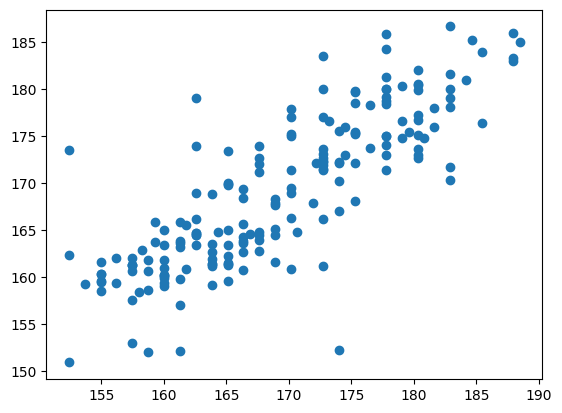

In [12]:
import matplotlib.pyplot as plt

plt.plot(y_test,y_pred,'o')
plt.show()

In [1]:
from joblib import dump

# Save model
dump(model, "model.joblib")

NameError: name 'model' is not defined